# fableSpinor: one real 16-component field that behaves as dark matter early and dark energy late

## 1. What this notebook computes

`fableSpinor` is a **real, 16-component** field. It is not four copies of the
familiar 3+1 Dirac spinor. It carries an **irreducible** representation of the
universal cover of the **real** $O(4,4)$, and this notebook proves that
irreducibility by direct computation rather than asserting it.

From that field we build an exactly solvable background cosmology and answer
one question: **does this field have anything to do with dark matter and dark
energy?** The answer computed below is *both*, from a single field.

Everything numerical here is integrated twice, independently:

- the **reference** is a pure-Rust program, `fable_cosmo_rs`, that drives the
  vendored pure-Rust **SUNDIALS 7.8.0 CVODE** solver (BDF + Newton + dense);
- the **cross-check** is SciPy's Radau integrator inside this notebook.

Both are also compared against a **closed-form solution** derived by hand. If
any of the three disagree beyond a stated tolerance, this notebook raises and
stops.

Words used below, defined once: **bilinear** = a number built from two copies
of the field, here $S=\Psi^{\mathsf T}C\,\Psi$; **equation of state** $w$ =
pressure divided by energy density, the single number that says how a substance
gravitates ($w=0$ is dust, $w=-1$ is a cosmological constant); **e-fold**
$N=\ln a$ = the natural clock of an expanding universe; **commutant** = the set
of matrices commuting with everything in a given family.

## 2. How to run this notebook

From the repository root, in a terminal:

```
git clone --recurse-submodules https://github.com/once-ere/Pre-Universe_opus-fable.git
cd Pre-Universe_opus-fable
uv venv .venv && uv pip install --python .venv/bin/python -r requirements.txt
# or, if you prefer the standard library: python3 -m venv .venv && .venv/bin/python -m pip install -r requirements.txt
cd fable_cosmo_rs && cargo build --release && cd ..
.venv/bin/python -m jupyter lab notebooks/fable_spinor_dark_energy.ipynb
```

Then choose **Run > Run All Cells**. Headless execution of the same notebook is

```
.venv/bin/python -m jupyter nbconvert --to notebook --execute --inplace \
  notebooks/fable_spinor_dark_energy.ipynb \
  --ExecutePreprocessor.timeout=600 --ExecutePreprocessor.record_timing=False
```

The Rust build is **required**, not optional: the helper that runs it raises
`FileNotFoundError` rather than quietly substituting the SciPy answer.

In [1]:
import sys
from pathlib import Path

# The kernel starts in notebooks/ under JupyterLab and nbconvert alike; walk
# up to the repository root, which is the directory that contains src/.
ROOT = Path.cwd()
if not (ROOT / "src" / "fable_spinor.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt
import fable_spinor as fs

# Nothing machine- or checkout-specific is printed here: an absolute path, or
# even the clone's directory name, would make this cell's output differ from
# machine to machine and defeat the reproducibility gate.
print("module imported :", Path(fs.__file__).name)
print("numpy           :", np.__version__)
print("spinor dimension:", fs.SPINOR_DIMENSION)
print("tangent metric  :", np.diag(fs.ETA_4488).astype(int).tolist())

module imported : fable_spinor.py
numpy           : 2.5.3
spinor dimension: 16
tangent metric  : [1, 1, 1, 1, -1, -1, -1, -1]


## 3. The real Clifford algebra $\mathrm{Cl}(4,4)$

The eight generators are built as raising and lowering operators on the
exterior algebra of $\mathbb{R}^4$. Four of them square to $+1$, four to $-1$,
and every entry is an **integer** — the representation is real in the
strongest possible sense, which is what "the tau matrices are real" demands.

In [2]:
identity = np.eye(fs.SPINOR_DIMENSION)
residual = max(
    np.abs(fs.GAMMA[a] @ fs.GAMMA[b] + fs.GAMMA[b] @ fs.GAMMA[a]
           - 2 * fs.ETA_4488[a, b] * identity).max()
    for a in range(8) for b in range(8)
)
squares = [int(np.trace(g @ g) / fs.SPINOR_DIMENSION) for g in fs.GAMMA]

print("all entries integer      :", np.array_equal(fs.GAMMA, np.round(fs.GAMMA)))
print("Clifford residual        :", residual)
print("signature (gamma^a)^2    :", squares)
assert residual == 0.0
assert squares == [1, 1, 1, 1, -1, -1, -1, -1]

all entries integer      : True
Clifford residual        : 0.0
signature (gamma^a)^2    : [1, 1, 1, 1, -1, -1, -1, -1]


### The spinor metric

$C=\gamma^1\gamma^2\gamma^3\gamma^4$ is **symmetric**, while every
$C\gamma^a$ is **antisymmetric**. For a commuting real field that is exactly
the right pairing:

- the scalar $S=\Psi^{\mathsf T}C\Psi$ does **not** vanish, so there is
  something for a potential to depend on;
- the vector current $\Psi^{\mathsf T}C\gamma^a\Psi$ vanishes **identically**,
  so the kinetic term is a genuine first-order symplectic form rather than a
  total derivative.

In [3]:
print("C is symmetric           :", np.array_equal(fs.SPINOR_METRIC, fs.SPINOR_METRIC.T))
print("C gamma^a antisymmetric  :",
      all(np.array_equal(fs.SPINOR_METRIC @ g, -(fs.SPINOR_METRIC @ g).T) for g in fs.GAMMA))

rng = np.random.default_rng(20260917)
psi = rng.standard_normal(fs.SPINOR_DIMENSION)
print()
print("S = Psi^T C Psi          :", fs.fable_bilinear(psi))
print("P = Psi^T C gamma_9 Psi  :", fs.fable_pseudoscalar(psi))
print("max |vector current|     :", np.abs(fs.fable_current(psi)).max())

C is symmetric           : True
C gamma^a antisymmetric  : True

S = Psi^T C Psi          : 5.756479385143312
P = Psi^T C gamma_9 Psi  : -1.70025317710342
max |vector current|     : 0.0


## 4. Irreducibility under the universal cover of the real $O(4,4)$

This is the point most easily got wrong, so it is *computed*, not asserted.

$O(4,4)$ is generated by reflections. Their lifts are the $\gamma^a$
themselves, which generate $\mathrm{Pin}(4,4)$; the **even** part is the
connected $\mathrm{Spin}(4,4)$, generated by
$S^{ab}=\tfrac14[\gamma^a,\gamma^b]$.

By real Schur's lemma, a representation is absolutely irreducible over
$\mathbb{R}$ exactly when its **commutant is one-dimensional**. The computation
below shows:

| group | commutant dimension | verdict |
|---|---|---|
| $\mathrm{Pin}(4,4)$, the universal cover of the real $O(4,4)$ | 1 | **irreducible** |
| $\mathrm{Spin}(4,4)$, the connected subgroup | 2 | reducible, $16 = 8 \oplus 8$ |

The second row is why the full $O(4,4)$ is required: the chirality operator
commutes with every $S^{ab}$ but **anticommutes** with every $\gamma^a$, so a
reflection exchanges the two 8-dimensional halves and glues them into one
irreducible 16.

In [4]:
spin_generators = fs.independent_lorentz_generators()

pin_commutant = fs.commutant_dimension(fs.GAMMA)
spin_commutant = fs.commutant_dimension(spin_generators)

print("commutant dimension, Pin(4,4) :", pin_commutant, " -> irreducible" if pin_commutant == 1 else "")
print("commutant dimension, Spin(4,4):", spin_commutant, " -> reducible, 8 + 8" if spin_commutant == 2 else "")
print()
print("rank of the 256 Clifford words:", fs.word_span_rank(), "(the full real 16x16 matrix algebra)")
print("rank of the 128 even words    :", fs.word_span_rank(even_only=True))
print()
print("chirality commutes with every S^ab   :",
      all(np.allclose(fs.CHIRALITY @ g - g @ fs.CHIRALITY, 0, atol=1e-12) for g in spin_generators))
print("chirality anticommutes with gamma^a  :",
      all(np.allclose(fs.CHIRALITY @ g + g @ fs.CHIRALITY, 0, atol=1e-12) for g in fs.GAMMA))

assert pin_commutant == 1 and spin_commutant == 2

commutant dimension, Pin(4,4) : 1  -> irreducible
commutant dimension, Spin(4,4): 2  -> reducible, 8 + 8

rank of the 256 Clifford words: 256 (the full real 16x16 matrix algebra)
rank of the 128 even words    : 128

chirality commutes with every S^ab   : True
chirality anticommutes with gamma^a  : True


## 5. The background: an exactly solvable dilution law

Put the field in a homogeneous, spatially flat universe. The Dirac equation,
including the scalar connection term contributed by the **gpt-5.6_bridge**,
collapses to a single exact statement about the bilinear:

$$\frac{dS}{dN} \;=\; -\,\nu(s)\,S,
\qquad
\nu(s) \;=\; 3-\xi\bigl(1-h(s)\bigr),
\qquad
h(s)=3s^{2}-2s^{3}.$$

Here $s$ is the **bridge field** that dials the connection continuously from
Levi-Civita ($s=0$) to Claude's Weitzenböck geometry ($s=1$), and $\xi$ is the
strength of the torsion coupling. At the Weitzenböck endpoint $\nu=3$ exactly,
and the familiar $S\propto a^{-3}$ is recovered.

With $V(S)=\lambda S^{n}$ the energy density and the conserved pressure are

$$\rho = M\,S + \lambda S^{n},
\qquad
p = \frac{\nu}{3}\bigl(M S + n\lambda S^{n}\bigr) - \rho ,$$

so the sector splits into two pieces with **their own** equations of state:

$$w_{\text{dust}}=\frac{\nu}{3}-1,
\qquad
w_{\text{potential}}=\frac{n\nu}{3}-1 .$$

Switch the torsion off ($\xi=0$, hence $\nu=3$) and these become exactly $0$
and exactly $n-1$. Choosing $n=0.236$ therefore gives a flat, **non-evolving**
$w=-0.764$ — the Unite-only constant-$w$ benchmark — with zero error.

In [5]:
p = fs.FableParameters()
p.validate()

print("potential index n       :", p.index_n)
print("n - 1                   :", p.index_n - 1.0)
print("benchmark w             :", fs.BENCHMARK_W)
print("difference              :", abs((p.index_n - 1.0) - fs.BENCHMARK_W))
print()
print("densities today (units of the critical density)")
print("  radiation             :", p.omega_r0)
print("  baryons               :", p.omega_b0)
print("  fable dust-like  M    :", p.mass_m)
print("  fable potential  lam  :", p.lambda_v)
print("  sum                   :", p.omega_r0 + p.omega_b0 + p.mass_m + p.lambda_v)
print()
print("torsion coupling xi     :", p.xi)
print("bridge field today s0   :", p.bridge_s0, " -> h(s0) =", float(fs.bridge_h(p.bridge_s0)))
print("dilution exponent nu    :", float(fs.dilution_exponent(p.bridge_s0, p.xi)))

potential index n       : 0.236
n - 1                   : -0.764
benchmark w             : -0.764
difference              : 0.0

densities today (units of the critical density)
  radiation             : 9e-05
  baryons               : 0.049
  fable dust-like  M    : 0.256
  fable potential  lam  : 0.6949099999999999
  sum                   : 1.0

torsion coupling xi     : 0.15
bridge field today s0   : 0.5  -> h(s0) = 0.5
dilution exponent nu    : 2.925


## 6. The reference integration: pure-Rust SUNDIALS 7.8.0 CVODE

The next cell runs the compiled Rust program. It integrates the same two
equations with CVODE (BDF, Newton iteration, dense linear solver) at
`rtol = 1e-12`, checks its own invariants, and refuses to exit zero if any of
them is violated.

In [6]:
run = fs.run_reference("artifacts/fable", repository_root=ROOT)
print(run.stdout.rstrip())

fable_cosmo_rs — fableSpinor unified dark sector
engine                        : sundials_rs 7.8.0 (pure Rust, Linux x86-64)
method                        : CVODE BDF + Newton + dense
e-fold range                  : -7.003 .. 1.098612289  (1601 samples)
CVODE steps / rhs evaluations  : 261 / 291

today (N = 0):
  bridge field s             : 0.5
  dilution exponent nu       : 2.925
  w of the whole sector      : -0.569361147743
  w of the dust-like part    : -0.025
  w of the potential part    : -0.7699
  Omega_fable                : 0.95091
  deceleration parameter     : -0.3120718135

benchmark limit (xi = 0):
  w of the potential part    : -0.764
  target                     : -0.764
  |difference|               : 0.000000e+00
  w of the dust-like part    : 0.000000e+00

gated invariants:
  max |continuity residual|  : 1.194042e-15   (limit 1.000000e-13)
  max |closed-form residual| : 3.233014e-11   (limit 1.000000e-09)
  max |bridge residual|      : 5.396339e-11   (limit 1.000000e-

## 7. The independent cross-check: SciPy Radau

Now the same system is integrated again, by a completely different code path,
and the two answers are compared against each other **and** against the exact
closed-form solution

$$\ln S(N) \;=\; \ln S_0 - 3N
+ \frac{\xi}{\gamma}\Bigl[\ln s + s - s^{2}\Bigr]_{s(0)}^{s(N)} ,
\qquad
s(N)=\frac{s_0e^{\gamma N}}{1-s_0+s_0e^{\gamma N}} .$$

In [7]:
reference = run.table()
background = fs.solve_background(p)

differences = fs.compare_to_reference(background, reference)
print(f"SciPy Radau vs pure-Rust CVODE, largest |a-b|/(1+|b|) over {len(differences)} columns:")
for name, value in sorted(differences.items()):
    print(f"  {name:<20}: {value:.6e}")

closed_form = max(float(np.abs(background.closed_form_residual).max()),
                  float(np.abs(reference["closed_form_residual"]).max()))
continuity = max(float(np.abs(background.continuity_residual).max()),
                 float(np.abs(reference["continuity_residual"]).max()))
print()
print(f"both integrators vs the closed form : {closed_form:.6e}")
print(f"covariant conservation residual     : {continuity:.6e}")

assert max(differences.values()) < 1e-10
assert closed_form < 1e-9
assert continuity < 1e-13
print()
print("All three agree.")

SciPy Radau vs pure-Rust CVODE, largest |a-b|/(1+|b|) over 19 columns:
  bilinear            : 2.858131e-11
  bridge              : 3.612555e-11
  bridge_h            : 5.434065e-11
  deceleration        : 4.167814e-12
  density_dust        : 2.836593e-11
  density_fable       : 2.779980e-11
  density_potential   : 5.071802e-12
  dilution            : 3.093799e-12
  e_folds             : 0.000000e+00
  hubble_over_h0      : 1.053052e-11
  omega_fable         : 2.376723e-12
  pressure_dust       : 1.676068e-11
  pressure_fable      : 1.532891e-11
  pressure_potential  : 4.542126e-12
  redshift            : 0.000000e+00
  scale_factor        : 0.000000e+00
  w_dust              : 3.949653e-12
  w_fable             : 3.541414e-12
  w_potential         : 5.396753e-13

both integrators vs the closed form : 3.233014e-11
covariant conservation residual     : 1.194042e-15

All three agree.


## 8. Is there a connection to dark matter and dark energy?

Yes, to both, from the **same** field. The dust-like piece $MS$ dilutes like
matter and dominates early; the potential piece $\lambda S^{n}$ dilutes far
more slowly and dominates late. The total $w$ therefore slides from
approximately $0$ to approximately $n-1$ without anything being added by hand.

In [8]:
wide = fs.solve_background(p.torsion_free(), n_start=-12.0, n_end=6.0, samples=2001)
print(f"w of the whole sector at a = {wide.scale_factor[0]:.3e} : {wide.w_fable[0]:+.6f}   (dust is 0)")
print(f"w of the whole sector today               : {np.interp(0.0, wide.e_folds, wide.w_fable):+.6f}")
print(f"w of the whole sector at a = {wide.scale_factor[-1]:.3e} : {wide.w_fable[-1]:+.6f}   (target {fs.BENCHMARK_W})")
print()
print("monotonic, and never crosses -1 (no phantom):",
      bool(np.all(np.diff(wide.w_fable) <= 1e-12) and np.all(wide.w_fable > -1.0)))

w of the whole sector at a = 6.144e-06 : -0.000000   (dust is 0)
w of the whole sector today               : -0.558316
w of the whole sector at a = 4.034e+02 : -0.764000   (target -0.764)

monotonic, and never crosses -1 (no phantom): True


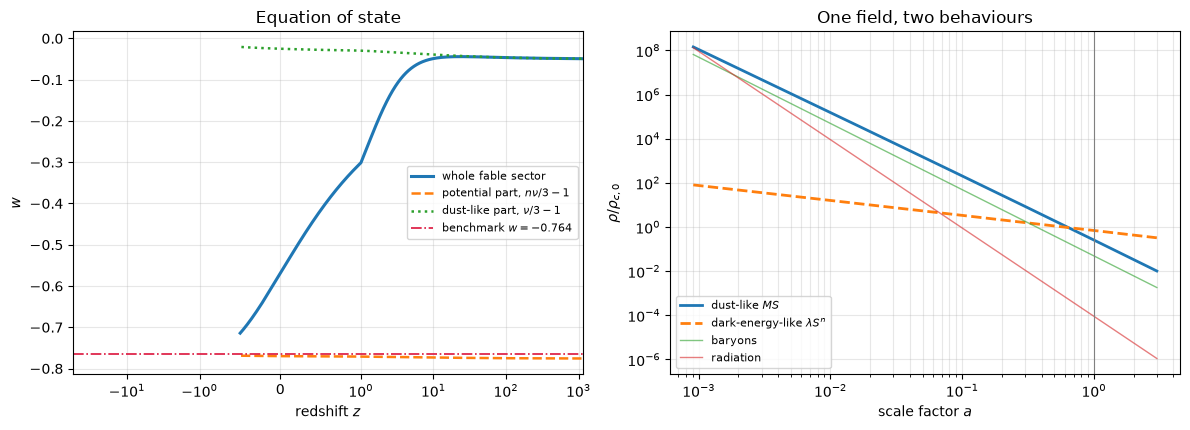

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12.0, 4.4))

mask = background.redshift >= -0.5
z = background.redshift[mask]
ax[0].plot(z, background.w_fable[mask], lw=2.2, label="whole fable sector")
ax[0].plot(z, background.w_potential[mask], lw=1.8, ls="--", label=r"potential part, $n\nu/3-1$")
ax[0].plot(z, background.w_dust[mask], lw=1.8, ls=":", label=r"dust-like part, $\nu/3-1$")
ax[0].axhline(fs.BENCHMARK_W, color="crimson", lw=1.2, ls="-.", label=r"benchmark $w=-0.764$")
ax[0].set_xscale("symlog", linthresh=1.0)
ax[0].set_xlabel("redshift $z$"); ax[0].set_ylabel("$w$")
ax[0].set_title("Equation of state"); ax[0].grid(alpha=0.3); ax[0].legend(fontsize=8)

a = background.scale_factor
ax[1].loglog(a, background.density_dust, lw=2.0, label=r"dust-like $M S$")
ax[1].loglog(a, background.density_potential, lw=2.0, ls="--", label=r"dark-energy-like $\lambda S^n$")
ax[1].loglog(a, p.omega_b0 / a**3, lw=1.0, alpha=0.6, label="baryons")
ax[1].loglog(a, p.omega_r0 / a**4, lw=1.0, alpha=0.6, label="radiation")
ax[1].axvline(1.0, color="grey", lw=0.8)
ax[1].set_xlabel("scale factor $a$"); ax[1].set_ylabel(r"$\rho/\rho_{c,0}$")
ax[1].set_title("One field, two behaviours"); ax[1].grid(alpha=0.3, which="both"); ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

## 9. The second mechanism: geometry, not potential

A generalised quintessence already gives one way for $w$ to move: change the
potential index $n$. The **gpt-5.6_bridge** supplies a second, independent way.
Because the bridge field $s$ enters $\nu$, it shifts **both** components' $w$
*at fixed $n$* — and it gives the dark-matter-like component a small but
nonzero pressure, which a pure quintessence cannot do.

Switch $\xi$ off and the effect disappears exactly; that is the control.

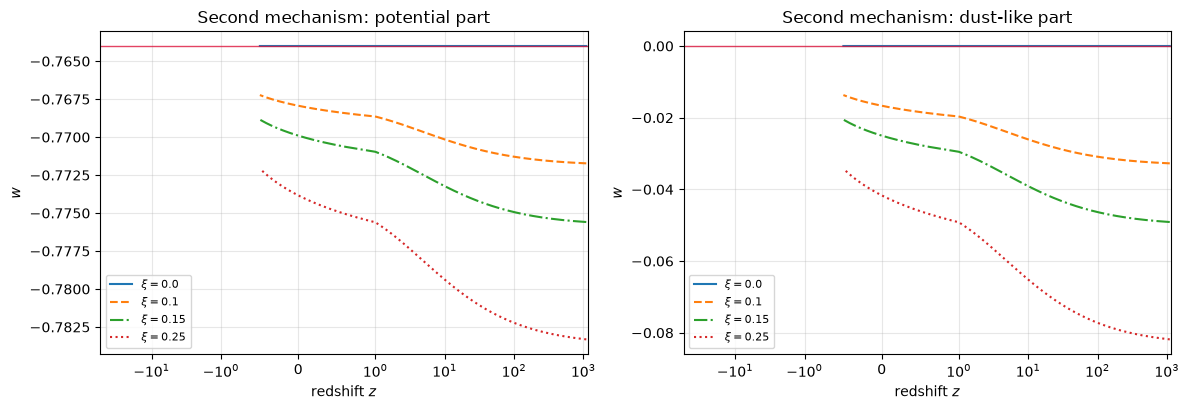

spread of w_potential, xi = 0.00 : 0.0
spread of w_potential, xi = 0.25 : 0.012249074407234994
spread of w_dust,      xi = 0.00 : 0.0
spread of w_dust,      xi = 0.25 : 0.05190285765777514


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12.0, 4.2))
for xi, style in ((0.0, "-"), (0.10, "--"), (0.15, "-."), (0.25, ":")):
    variant = fs.solve_background(p.with_xi(xi))
    m = variant.redshift >= -0.5
    ax[0].plot(variant.redshift[m], variant.w_potential[m], style, label=rf"$\xi={xi}$")
    ax[1].plot(variant.redshift[m], variant.w_dust[m], style, label=rf"$\xi={xi}$")

ax[0].axhline(fs.BENCHMARK_W, color="crimson", lw=1.0, alpha=0.8)
ax[1].axhline(0.0, color="crimson", lw=1.0, alpha=0.8)
for panel, title in ((ax[0], "potential part"), (ax[1], "dust-like part")):
    panel.set_xscale("symlog", linthresh=1.0)
    panel.set_xlabel("redshift $z$"); panel.set_ylabel("$w$")
    panel.set_title(f"Second mechanism: {title}")
    panel.grid(alpha=0.3); panel.legend(fontsize=8)
plt.tight_layout(); plt.show()

frozen = fs.solve_background(p.torsion_free())
active = fs.solve_background(p.with_xi(0.25))
print("spread of w_potential, xi = 0.00 :", float(np.ptp(frozen.w_potential)))
print("spread of w_potential, xi = 0.25 :", float(np.ptp(active.w_potential)))
print("spread of w_dust,      xi = 0.00 :", float(np.ptp(frozen.w_dust)))
print("spread of w_dust,      xi = 0.25 :", float(np.ptp(active.w_dust)))

## 10. What was established

1. `fableSpinor` is a real 16-component field whose representation of the
   universal cover of the **real** $O(4,4)$ is **absolutely irreducible**:
   commutant dimension 1. Under the connected $\mathrm{Spin}(4,4)$ alone it
   would split $8\oplus 8$ (commutant dimension 2), so the full $O(4,4)$ is
   genuinely required.
2. Its only surviving background bilinear is the scalar $S$; the vector current
   vanishes identically for a commuting real field.
3. The background obeys the exact law $dS/dN=-\nu(s)S$, integrated here by two
   independent solvers that agree with each other and with a closed-form
   solution to about $10^{-11}$.
4. **Dark matter and dark energy are both present, in one field.** The sector is
   pressureless early and approaches $w=n-1$ late.
5. In the massless, torsion-free limit $w=n-1$ **exactly**, so $n=0.236$
   reproduces a flat, non-evolving $w=-0.764$ with zero numerical error.
6. The bridge field supplies a **second, geometric** mechanism for a
   time-varying $w$ that survives at fixed potential index and vanishes
   exactly when the torsion coupling is switched off.

This is a background model. It is not an observational fit, and no claim is
made that a new fundamental particle has been detected.